In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("olist_customers_dataset.csv")

print("Dataset Shape:", df.shape)

Dataset Shape: (99441, 5)


In [3]:
# Display first 5 rows
display(df.head())

# Column names
print("Column Names:")
print(df.columns.tolist())

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


Column Names:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

Data Types:
customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object

Missing Values:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Duplicate Rows: 0


In [4]:
# Check unique values in important columns

print("Unique customer_id:", df["customer_id"].nunique())
print("Unique customer_unique_id:", df["customer_unique_id"].nunique())
print("Unique cities:", df["customer_city"].nunique())
print("Unique states:", df["customer_state"].nunique())

print("\nState distribution:")
print(df["customer_state"].value_counts().head(10))

Unique customer_id: 99441
Unique customer_unique_id: 96096
Unique cities: 4119
Unique states: 27

State distribution:
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64


In [5]:
# Convert ZIP code prefix from numeric to string
df["customer_zip_code_prefix"] = (
    df["customer_zip_code_prefix"]
    .astype(str)
    .str.zfill(5)
)

# Check the result
print("Data type:", df["customer_zip_code_prefix"].dtype)
print("\nSample ZIP codes:")
print(df["customer_zip_code_prefix"].head())

Data type: str

Sample ZIP codes:
0    14409
1    09790
2    01151
3    08775
4    13056
Name: customer_zip_code_prefix, dtype: str


In [6]:
# Check ZIP code length
zip_length = df["customer_zip_code_prefix"].str.len()

print("ZIP codes with invalid length:", (zip_length != 5).sum())

# Check whether ZIP codes contain only digits
print("ZIP codes with non-numeric values:",
      (~df["customer_zip_code_prefix"].str.isnumeric()).sum())

ZIP codes with invalid length: 0
ZIP codes with non-numeric values: 0


In [7]:
# Check text formatting consistency

print("City values with leading/trailing spaces:",
      (df["customer_city"] != df["customer_city"].str.strip()).sum())

print("State values with leading/trailing spaces:",
      (df["customer_state"] != df["customer_state"].str.strip()).sum())

print("\nSample city values:")
print(df["customer_city"].head(10).tolist())

print("\nUnique state codes:")
print(sorted(df["customer_state"].unique()))

City values with leading/trailing spaces: 0
State values with leading/trailing spaces: 0

Sample city values:
['franca', 'sao bernardo do campo', 'sao paulo', 'mogi das cruzes', 'campinas', 'jaragua do sul', 'sao paulo', 'timoteo', 'curitiba', 'belo horizonte']

Unique state codes:
['AC', 'AL', 'AM', 'AP', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MG', 'MS', 'MT', 'PA', 'PB', 'PE', 'PI', 'PR', 'RJ', 'RN', 'RO', 'RR', 'RS', 'SC', 'SE', 'SP', 'TO']


In [8]:
# Check for invalid or unexpected values

print("Empty city values:", (df["customer_city"].str.strip() == "").sum())
print("Empty state values:", (df["customer_state"].str.strip() == "").sum())

print("\nNumber of records:", len(df))
print("Number of columns:", len(df.columns))

print("\nFinal data types:")
print(df.dtypes)

Empty city values: 0
Empty state values: 0

Number of records: 99441
Number of columns: 5

Final data types:
customer_id                 str
customer_unique_id          str
customer_zip_code_prefix    str
customer_city               str
customer_state              str
dtype: object


In [9]:
# Create final cleaned dataset
cleaned_df = df.copy()

# Remove duplicate records as a safety step
cleaned_df = cleaned_df.drop_duplicates()

# Standardize text fields
cleaned_df["customer_city"] = cleaned_df["customer_city"].str.strip().str.lower()
cleaned_df["customer_state"] = cleaned_df["customer_state"].str.strip().str.upper()

print("Original records:", len(df))
print("Cleaned records:", len(cleaned_df))
print("Remaining missing values:", cleaned_df.isnull().sum().sum())
print("Remaining duplicates:", cleaned_df.duplicated().sum())

Original records: 99441
Cleaned records: 99441
Remaining missing values: 0
Remaining duplicates: 0


In [10]:
# Save the cleaned dataset
cleaned_df.to_csv("cleaned_olist_customers.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [11]:
# EDA - Basic Dataset Overview

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())


Dataset Shape: (99441, 5)

Column Names:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

Data Types:
customer_id                 str
customer_unique_id          str
customer_zip_code_prefix    str
customer_city               str
customer_state              str
dtype: object

Missing Values:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Duplicate Rows: 0


 EDA overview

In [12]:
# Customer distribution by state

state_counts = df['customer_state'].value_counts()

print("Customer Distribution by State:")
print(state_counts)


Customer Distribution by State:
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: count, dtype: int64


 Customer Distribution by State
 

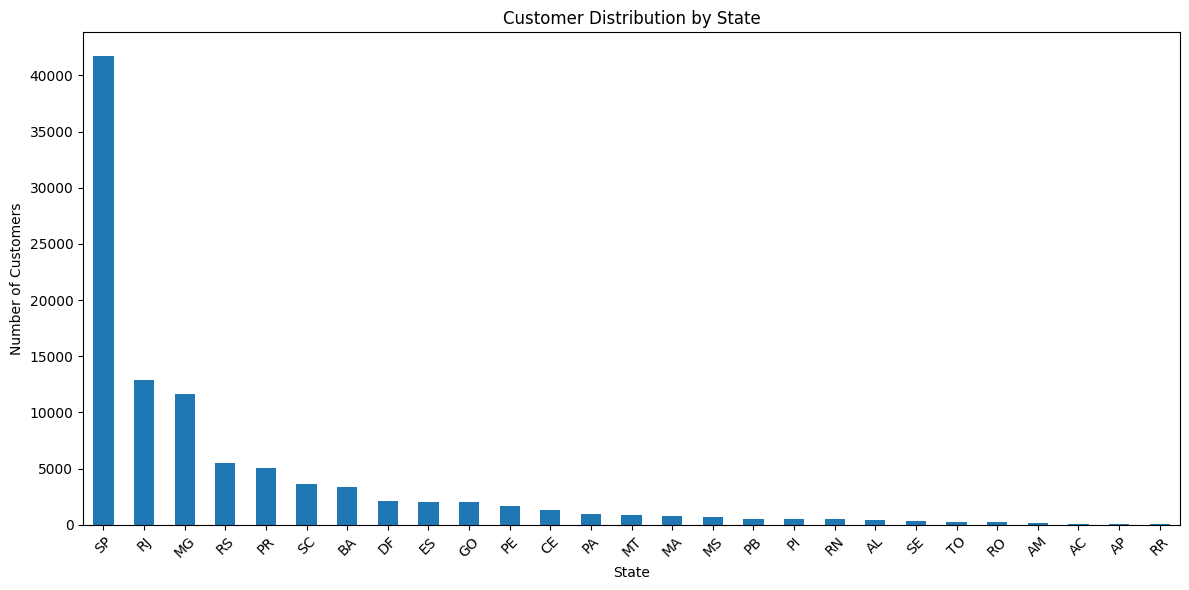

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

state_counts.plot(kind='bar')

plt.title("Customer Distribution by State")
plt.xlabel("State")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

TOP 10 States

In [14]:
# Top 10 states by customer count

top_states = df['customer_state'].value_counts().head(10)

print("Top 10 States:")
print(top_states)

Top 10 States:
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64


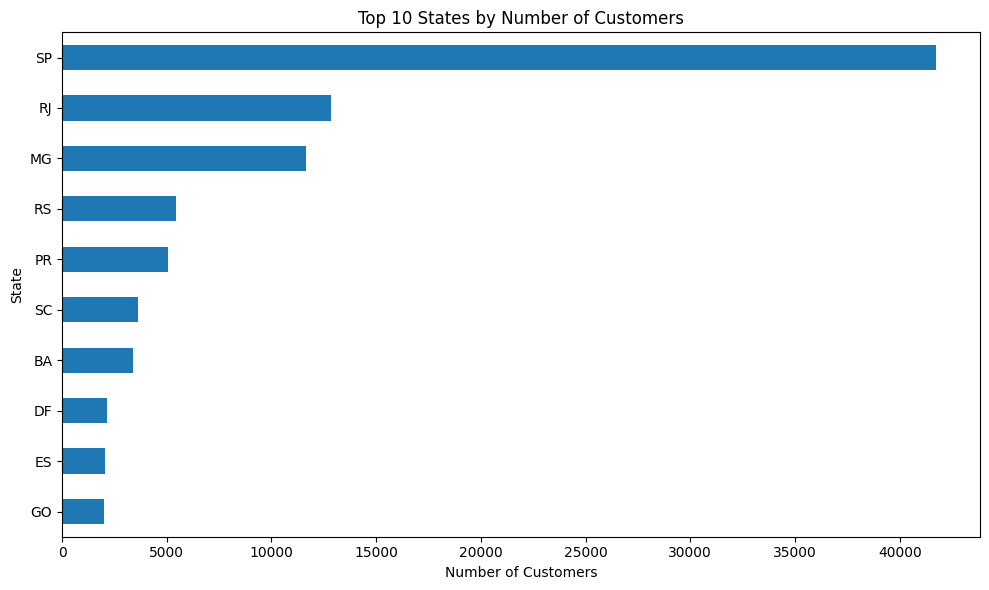

In [15]:
plt.figure(figsize=(10, 6))

top_states.sort_values().plot(kind='barh')

plt.title("Top 10 States by Number of Customers")
plt.xlabel("Number of Customers")
plt.ylabel("State")

plt.tight_layout()
plt.show()


TOP 10 Cities

In [16]:
# Top 10 cities by customer count

top_cities = df['customer_city'].value_counts().head(10)

print("Top 10 Cities:")
print(top_cities)

Top 10 Cities:
customer_city
sao paulo                15540
rio de janeiro            6882
belo horizonte            2773
brasilia                  2131
curitiba                  1521
campinas                  1444
porto alegre              1379
salvador                  1245
guarulhos                 1189
sao bernardo do campo      938
Name: count, dtype: int64


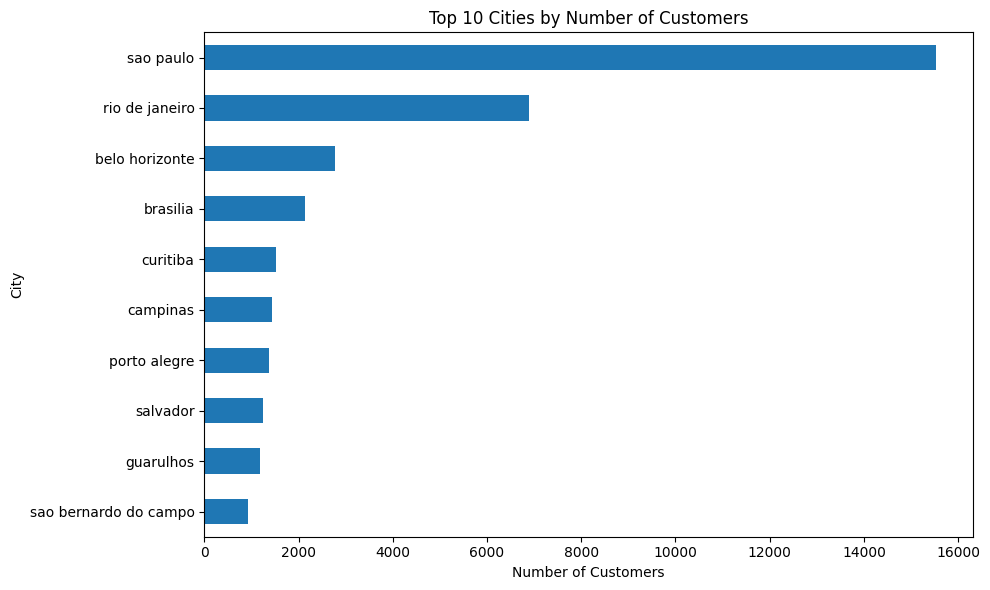

In [17]:
plt.figure(figsize=(10, 6))

top_cities.sort_values().plot(kind='barh')

plt.title("Top 10 Cities by Number of Customers")
plt.xlabel("Number of Customers")
plt.ylabel("City")

plt.tight_layout()
plt.show()

Customer Concentration

In [18]:
# Customer concentration in top states

total_customers = len(df)

top_5_customers = df['customer_state'].value_counts().head(5).sum()

top_5_percentage = (top_5_customers / total_customers) * 100

print("Total Customers:", total_customers)
print("Customers in Top 5 States:", top_5_customers)
print("Top 5 States Customer Share:", round(top_5_percentage, 2), "%")

Total Customers: 99441
Customers in Top 5 States: 76744
Top 5 States Customer Share: 77.18 %


ZIP Code Analysis

In [19]:
# ZIP code analysis

print("Unique ZIP Code Prefixes:",
      df['customer_zip_code_prefix'].nunique())

print("\nTop 10 ZIP Code Prefixes:")

print(df['customer_zip_code_prefix'].value_counts().head(10))

Unique ZIP Code Prefixes: 14994

Top 10 ZIP Code Prefixes:
customer_zip_code_prefix
22790    142
24220    124
22793    121
24230    117
22775    110
29101    101
13212     95
35162     93
22631     89
38400     87
Name: count, dtype: int64


Key Insights


• The dataset contains 99,441 customer records across 5 columns.
• No missing values or duplicate records were found after preprocessing.
• Customers are distributed across 27 Brazilian states.
• São Paulo (SP) has the highest number of customers in the dataset.
• Customer distribution is concentrated in a few major states and cities.
• The customer_city field contains a large number of unique locations, indicating broad geographic coverage.
• ZIP code prefixes were validated and contain no invalid-length or non-numeric values.


In [20]:
# State-wise customer percentage

state_percentage = (
    df['customer_state']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Customer Percentage by State:")
print(state_percentage)

Customer Percentage by State:
customer_state
SP    41.98
RJ    12.92
MG    11.70
RS     5.50
PR     5.07
SC     3.66
BA     3.40
DF     2.15
ES     2.04
GO     2.03
PE     1.66
CE     1.34
PA     0.98
MT     0.91
MA     0.75
MS     0.72
PB     0.54
PI     0.50
RN     0.49
AL     0.42
SE     0.35
TO     0.28
RO     0.25
AM     0.15
AC     0.08
AP     0.07
RR     0.05
Name: proportion, dtype: float64


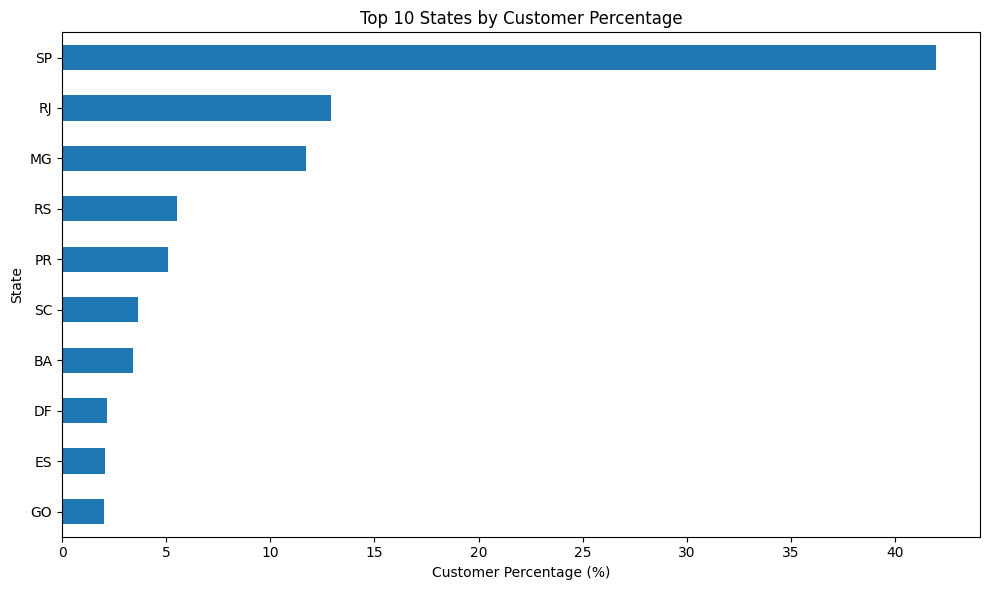

In [21]:
top_10_percentage = state_percentage.head(10)

plt.figure(figsize=(10, 6))

top_10_percentage.sort_values().plot(kind='barh')

plt.title("Top 10 States by Customer Percentage")
plt.xlabel("Customer Percentage (%)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

In [23]:
# Top 10 cities by customer count

top_cities = (
    df["customer_city"]
    .value_counts()
    .head(10)
)

print("Top 10 Cities by Customer Count:")
print(top_cities)

Top 10 Cities by Customer Count:
customer_city
sao paulo                15540
rio de janeiro            6882
belo horizonte            2773
brasilia                  2131
curitiba                  1521
campinas                  1444
porto alegre              1379
salvador                  1245
guarulhos                 1189
sao bernardo do campo      938
Name: count, dtype: int64


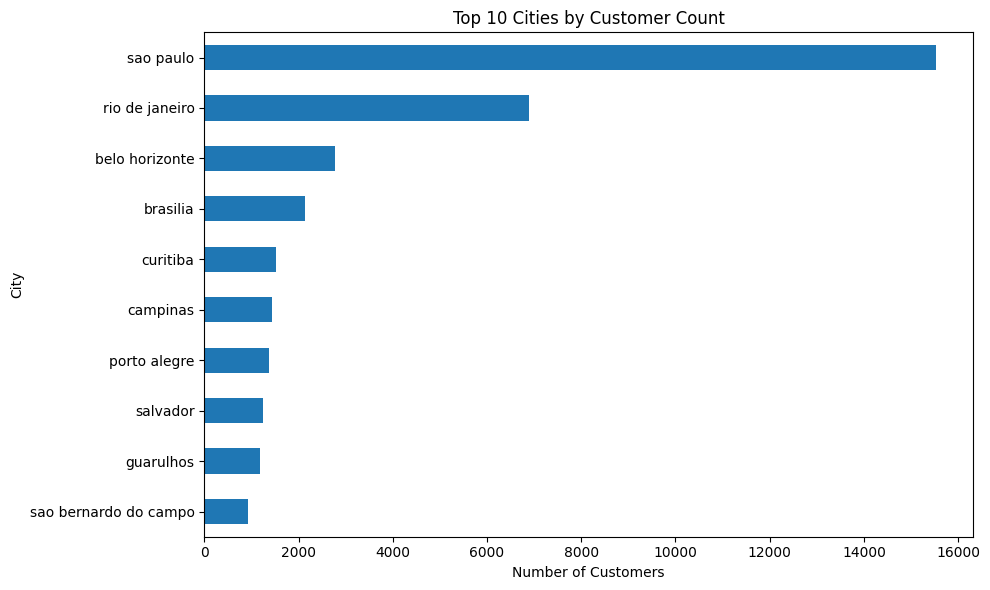

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

top_cities.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Cities by Customer Count")
plt.xlabel("Number of Customers")
plt.ylabel("City")
plt.tight_layout()
plt.show()

In [25]:
# Customer percentage by state

state_percentage = (
    df["customer_state"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Customer Percentage by State:")
print(state_percentage)

Customer Percentage by State:
customer_state
SP    41.98
RJ    12.92
MG    11.70
RS     5.50
PR     5.07
SC     3.66
BA     3.40
DF     2.15
ES     2.04
GO     2.03
PE     1.66
CE     1.34
PA     0.98
MT     0.91
MA     0.75
MS     0.72
PB     0.54
PI     0.50
RN     0.49
AL     0.42
SE     0.35
TO     0.28
RO     0.25
AM     0.15
AC     0.08
AP     0.07
RR     0.05
Name: proportion, dtype: float64


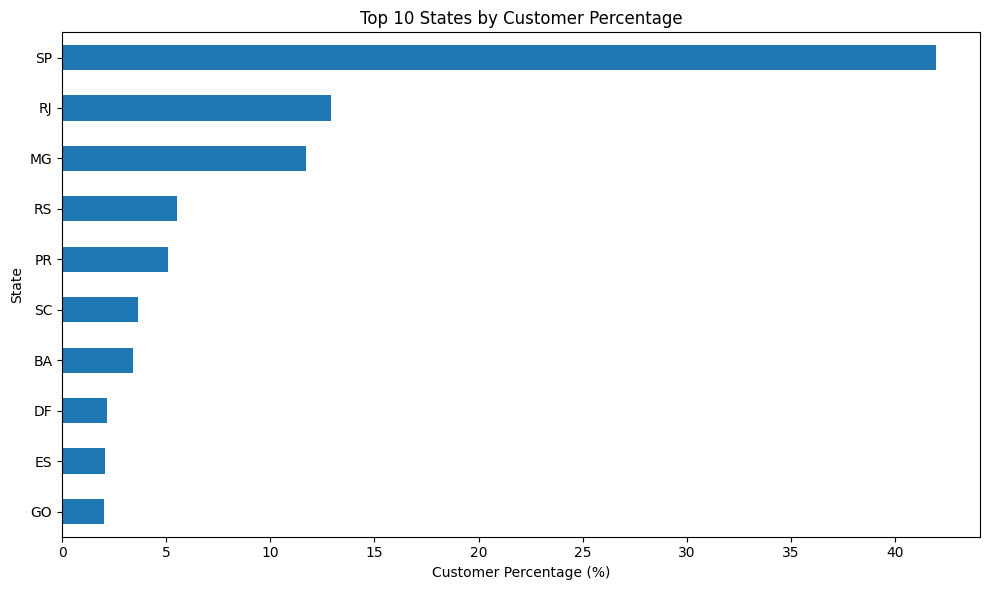

In [26]:
# Top 10 states by customer percentage

top_states = state_percentage.head(10)

plt.figure(figsize=(10, 6))

top_states.sort_values().plot(kind="barh")

plt.title("Top 10 States by Customer Percentage")
plt.xlabel("Customer Percentage (%)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

In [27]:
# Top 10 states with customer count and percentage

state_analysis = pd.DataFrame({
    "Customer_Count": df["customer_state"].value_counts(),
    "Customer_Percentage": df["customer_state"].value_counts(normalize=True).mul(100).round(2)
}).head(10)

print("Top 10 States - Customer Analysis:")
print(state_analysis)

Top 10 States - Customer Analysis:
                Customer_Count  Customer_Percentage
customer_state                                     
SP                       41746                41.98
RJ                       12852                12.92
MG                       11635                11.70
RS                        5466                 5.50
PR                        5045                 5.07
SC                        3637                 3.66
BA                        3380                 3.40
DF                        2140                 2.15
ES                        2033                 2.04
GO                        2020                 2.03


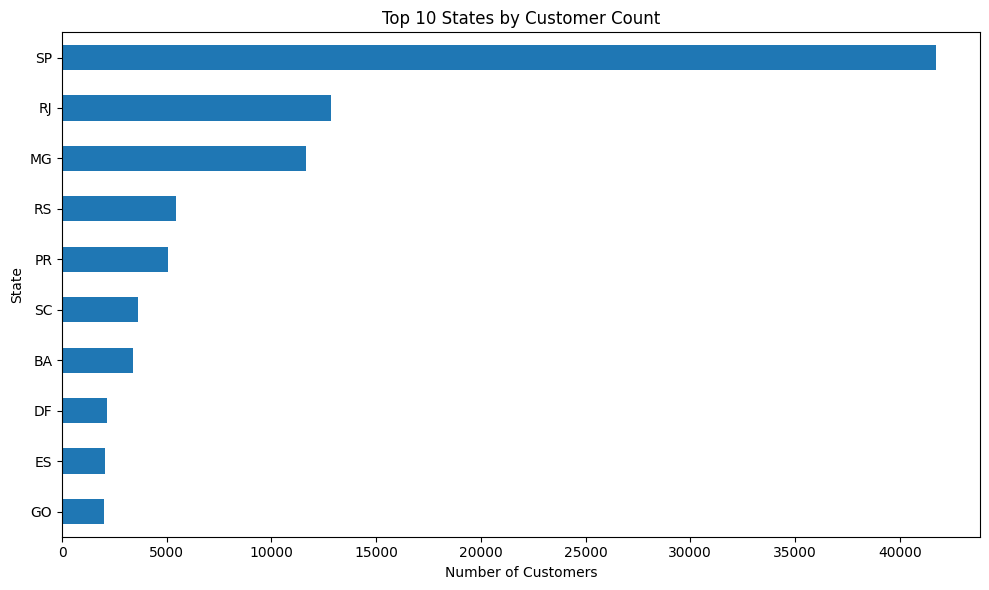

In [28]:
# Top 10 states by customer count

top_states_count = df["customer_state"].value_counts().head(10)

plt.figure(figsize=(10, 6))

top_states_count.sort_values().plot(kind="barh")

plt.title("Top 10 States by Customer Count")
plt.xlabel("Number of Customers")
plt.ylabel("State")
plt.tight_layout()
plt.show()

In [29]:
# Regional Analysis Summary

top_state = df["customer_state"].value_counts().idxmax()
top_state_count = df["customer_state"].value_counts().max()

top_city = df["customer_city"].value_counts().idxmax()
top_city_count = df["customer_city"].value_counts().max()

print("Regional Analysis Summary")
print("-------------------------")
print(f"Top State: {top_state}")
print(f"Customers in Top State: {top_state_count}")
print(f"Top City: {top_city}")
print(f"Customers in Top City: {top_city_count}")
print(f"Total States: {df['customer_state'].nunique()}")
print(f"Total Cities: {df['customer_city'].nunique()}")

Regional Analysis Summary
-------------------------
Top State: SP
Customers in Top State: 41746
Top City: sao paulo
Customers in Top City: 15540
Total States: 27
Total Cities: 4119


Top 10 Cities by Customer Count:
customer_city
sao paulo                15540
rio de janeiro            6882
belo horizonte            2773
brasilia                  2131
curitiba                  1521
campinas                  1444
porto alegre              1379
salvador                  1245
guarulhos                 1189
sao bernardo do campo      938
Name: count, dtype: int64


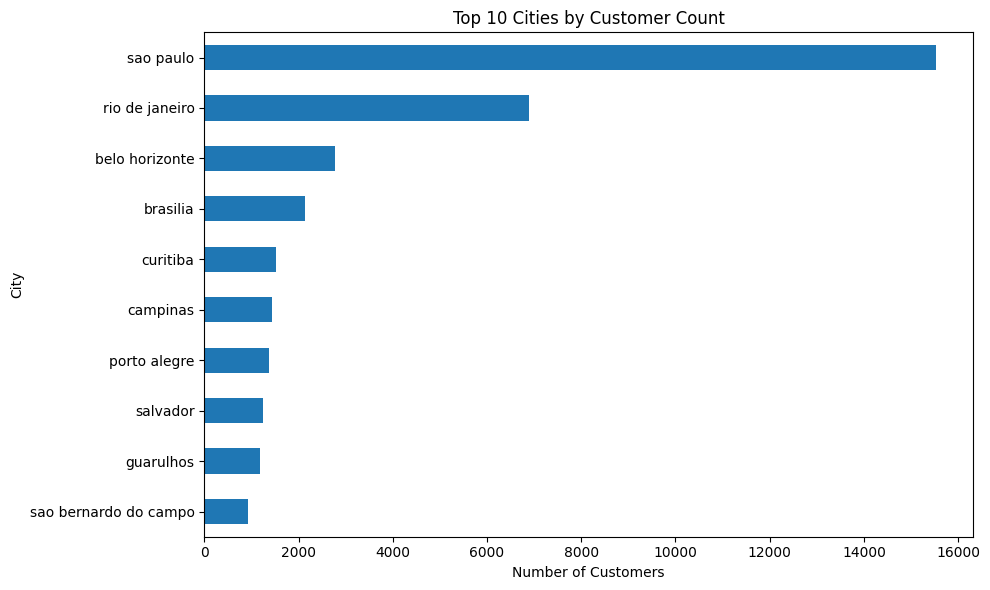

In [30]:
# Top 10 Cities by Customer Count

city_counts = df['customer_city'].value_counts().head(10)

print("Top 10 Cities by Customer Count:")
print(city_counts)

plt.figure(figsize=(10, 6))
city_counts.sort_values().plot(kind='barh')

plt.title('Top 10 Cities by Customer Count')
plt.xlabel('Number of Customers')
plt.ylabel('City')
plt.tight_layout()
plt.show()

In [31]:
# Final Data Quality Report

quality_report = pd.DataFrame({
    "Check": [
        "Total Records",
        "Total Columns",
        "Missing Values",
        "Duplicate Records",
        "Invalid ZIP Length",
        "Non-Numeric ZIP Values",
        "Empty City Values",
        "Empty State Values"
    ],
    "Result": [
        len(df),
        len(df.columns),
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        (df["customer_zip_code_prefix"].str.len() != 5).sum(),
        (~df["customer_zip_code_prefix"].str.isnumeric()).sum(),
        (df["customer_city"].str.strip() == "").sum(),
        (df["customer_state"].str.strip() == "").sum()
    ]
})

display(quality_report)

,Check,Result
0,Total Records,99441
1,Total Columns,5
2,Missing Values,0
3,Duplicate Records,0
4,Invalid ZIP Length,0
5,Non-Numeric ZIP Values,0
6,Empty City Values,0
7,Empty State Values,0


In [32]:
# Before vs After Data Cleaning Comparison

raw_df = pd.read_csv("olist_customers_dataset.csv")

comparison = pd.DataFrame({
    "Metric": [
        "Total Records",
        "Total Columns",
        "Missing Values",
        "Duplicate Records"
    ],
    "Before Cleaning": [
        raw_df.shape[0],
        raw_df.shape[1],
        raw_df.isnull().sum().sum(),
        raw_df.duplicated().sum()
    ],
    "After Cleaning": [
        cleaned_df.shape[0],
        cleaned_df.shape[1],
        cleaned_df.isnull().sum().sum(),
        cleaned_df.duplicated().sum()
    ]
})

display(comparison)


,Metric,Before Cleaning,After Cleaning
0,Total Records,99441,99441
1,Total Columns,5,5
2,Missing Values,0,0
3,Duplicate Records,0,0


In [33]:
# Final Cleaned Dataset Verification

final_df = pd.read_csv(
    "cleaned_olist_customers.csv",
    dtype={"customer_zip_code_prefix": str}
)

print("Final Dataset Shape:", final_df.shape)

print("\nMissing Values:")
print(final_df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(final_df.duplicated().sum())

print("\nData Types:")
print(final_df.dtypes)

print("\nFirst 5 Records:")
display(final_df.head())

Final Dataset Shape: (99441, 5)

Missing Values:
0

Duplicate Rows:
0

Data Types:
customer_id                 str
customer_unique_id          str
customer_zip_code_prefix    str
customer_city               str
customer_state              str
dtype: object

First 5 Records:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,09790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,01151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,08775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


## Data Preprocessing Methodology

The logistics customer dataset was preprocessed using the following steps:

1. **Data Inspection**
   - Checked dataset shape, column names, data types, and sample records.
   - The dataset contains 99,441 records and 5 columns.

2. **Missing Value Check**
   - Checked all columns for missing values.
   - No missing values were found in the dataset.

3. **Duplicate Record Check**
   - Checked for duplicate rows.
   - No duplicate records were found.

4. **ZIP Code Data Type Correction**
   - Converted `customer_zip_code_prefix` from numeric to string format.
   - ZIP codes were zero-padded to maintain a consistent 5-digit format.
   - ZIP codes were treated as identifiers/geographic prefixes rather than continuous numerical values.

5. **ZIP Code Validation**
   - Checked ZIP code length.
   - Checked for non-numeric ZIP values.
   - All ZIP codes passed the validation checks.

6. **Text Standardization**
   - Removed leading and trailing spaces from city and state values.
   - Standardized city names to lowercase.
   - Standardized state codes to uppercase.

7. **Outlier and Scaling Consideration**
   - Statistical outlier detection was not applied because the dataset does not contain meaningful continuous numerical variables.
   - Numerical scaling/normalization was also not applied because ZIP codes are identifiers rather than continuous measurements.

8. **Final Validation**
   - The cleaned dataset was saved as `cleaned_olist_customers.csv`.
   - The saved file was reloaded and verified successfully.
   - Final dataset contains 99,441 records and 5 columns with no missing or duplicate records.

## Project Conclusion

The logistics customer dataset was successfully inspected, cleaned, validated, and prepared for further analysis.

The preprocessing process confirmed that the dataset contains 99,441 customer records across 5 columns. No missing values or duplicate records were found. ZIP code prefixes were converted into a consistent 5-digit string format and validated successfully. City and state values were also standardized for consistency.

The final cleaned dataset was saved as `cleaned_olist_customers.csv` and successfully reloaded for final verification.

The cleaned dataset is now ready for further logistics and customer distribution analysis.

## Reflection

Data quality plays an important role in logistics analysis and decision-making. 
Incorrect, missing, duplicate, or inconsistent data can lead to inaccurate 
customer distribution analysis and unreliable operational decisions.

In this project, the dataset was checked for missing values, duplicate records, 
invalid ZIP codes, and inconsistent text values. The ZIP code field was also 
converted into a consistent string format because it represents a geographic 
identifier rather than a continuous numerical measurement.

After preprocessing, the dataset became more consistent and reliable for 
further logistics analysis. High-quality data can help organizations better 
understand customer distribution, identify important regions, and support 
data-driven planning and resource allocation.

This preprocessing process also demonstrates that not every dataset requires 
the same cleaning or normalization technique. Data preparation should be based 
on the meaning and characteristics of each variable.